# Classificação de objetos astronômicos: galáxia, quasar ou estrela

## 1. O problema

**Contexto.** Levantamentos do céu como o Sloan Digital Sky Survey (SDSS) medem milhões de objetos pelo brilho em cinco filtros de cor (u, g, r, i, z) e pelo redshift. Confirmar o que cada objeto é pelo espectro completo é caro e lento, então a pergunta é se essas medidas, mais simples, bastam para classificá-lo.

**Objetivo.** Construir um modelo que diga se um objeto é uma galáxia (`GALAXY`), um quasar (`QSO`) ou uma estrela (`STAR`) a partir da posição no céu, das magnitudes nos cinco filtros, do redshift, do tipo espectral e da população de cor.

**O que se prevê.** Classificação multiclasse, com três classes.

**Target.** `class`.

**Como os resultados podem ser usados.**
- **Triagem para espectroscopia:** priorizar os objetos com maior probabilidade de serem quasares, que são raros e mais valiosos para estudo.
- **Catálogos em larga escala:** classificar milhões de objetos sem esperar pelo espectro de cada um.
- **Revisão dirigida:** objetos com a probabilidade dividida entre duas classes vão para conferência humana, e o resto segue automático.

As classes são desbalanceadas, e errar a classe rara custa mais, por isso a métrica usada é a balanced accuracy.

## 2. O dataset (resumo)

- **Arquivos:** `data/train.csv` (com a classe) e `data/test.csv` (sem a classe, para gerar a submissão).
- **Tamanho:** 577.347 registros de treino e 247.435 de teste. O treino tem 12 colunas: `id`, 10 atributos e o target.
- **Tipos:** 8 atributos numéricos contínuos, 2 categóricos nominais e o target categórico com 3 classes.
- **Classes:** GALAXY 65,4%, QSO 20,3% e STAR 14,3%.

O detalhamento está na seção 2, abaixo, e em `stellarClasses-documento.md`.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## Vars:

In [3]:
TARGET = 'class'
N_FOLDS = 5
RANDOM_STATE = 42

In [4]:
le = LabelEncoder()
ohe = OneHotEncoder()

In [ ]:
train_df = pd.read_csv('ml/data/train.csv')
target_col = train_df[TARGET]
train_df=  train_df.drop(columns=['id', TARGET]) # Remove the id and class cols

test_df = pd.read_csv('ml/data/test.csv')

## 2. Dataset

Registros, atributos, tipo de cada variável e o que cada uma mede. O `id` e o `class` já saíram de `train_df` na célula anterior; a classe está em `target_col`.

In [ ]:
print('treino:', train_df.shape[0], 'registros x', train_df.shape[1], 'atributos (sem id e sem class)')
print('teste:', test_df.shape[0], 'registros x', test_df.shape[1] - 1, 'atributos (sem id)')

categoricas = train_df.select_dtypes(exclude='number').columns.tolist()
numericas = train_df.select_dtypes(include='number').columns.tolist()
print('categóricas:', categoricas)
print('numéricas:', numericas)
print(f'target: {TARGET}, categórica com {target_col.nunique()} classes: {sorted(target_col.unique())}')

descricao = {
    'alpha': 'ascensão reta: posição no céu, em graus (0 a 360)',
    'delta': 'declinação: posição no céu, em graus (-90 a 90)',
    'u': 'magnitude no filtro ultravioleta',
    'g': 'magnitude no filtro verde',
    'r': 'magnitude no filtro vermelho',
    'i': 'magnitude no filtro infravermelho próximo',
    'z': 'magnitude no filtro infravermelho',
    'redshift': 'desvio para o vermelho: quanto a luz se esticou com o afastamento do objeto',
    'spectral_type': 'tipo espectral (O/B, A/F, G/K, M)',
    'galaxy_population': 'população de cor (Blue_Cloud ou Red_Sequence)',
}
pd.DataFrame({
    'tipo pandas': train_df.dtypes.astype(str),
    'natureza': ['categórica nominal' if c in categoricas else 'numérica contínua' for c in train_df.columns],
    'valores distintos': train_df.nunique(),
    'descrição': pd.Series(descricao),
})

treino: 577347 registros x 10 atributos (sem id e sem class)
teste: 247435 registros x 10 atributos (sem id)
categóricas: ['spectral_type', 'galaxy_population']
numéricas: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
target: class, categórica com 3 classes: ['GALAXY', 'QSO', 'STAR']


,tipo pandas,natureza,valores distintos,descrição
alpha,float64,numérica contínua,439819,"ascensão reta: posição no céu, em graus (0 a 360)"
delta,float64,numérica contínua,444062,"declinação: posição no céu, em graus (-90 a 90)"
u,float64,numérica contínua,577347,magnitude no filtro ultravioleta
g,float64,numérica contínua,577347,magnitude no filtro verde
r,float64,numérica contínua,577347,magnitude no filtro vermelho
i,float64,numérica contínua,577347,magnitude no filtro infravermelho próximo
z,float64,numérica contínua,577347,magnitude no filtro infravermelho
redshift,float64,numérica contínua,573975,desvio para o vermelho: quanto a luz se esticou com o afastamento do objeto
spectral_type,object,categórica nominal,4,"tipo espectral (O/B, A/F, G/K, M)"
galaxy_population,object,categórica nominal,2,população de cor (Blue_Cloud ou Red_Sequence)


- **Magnitude é escala invertida:** quanto menor o número, mais brilhante o objeto. As cinco magnitudes medem o mesmo objeto em comprimentos de onda diferentes, então devem andar juntas.
- **`alpha` e `delta` são só a posição no céu.** Não há razão física para a posição dizer o tipo do objeto, o que é conferido na correlação e na separação por classe.
- **As duas categóricas não têm ordem útil para o modelo** e têm poucos valores (4 e 2), então são candidatas naturais ao one-hot.

## 3. Análise exploratória

### Distribuição das variáveis numéricas

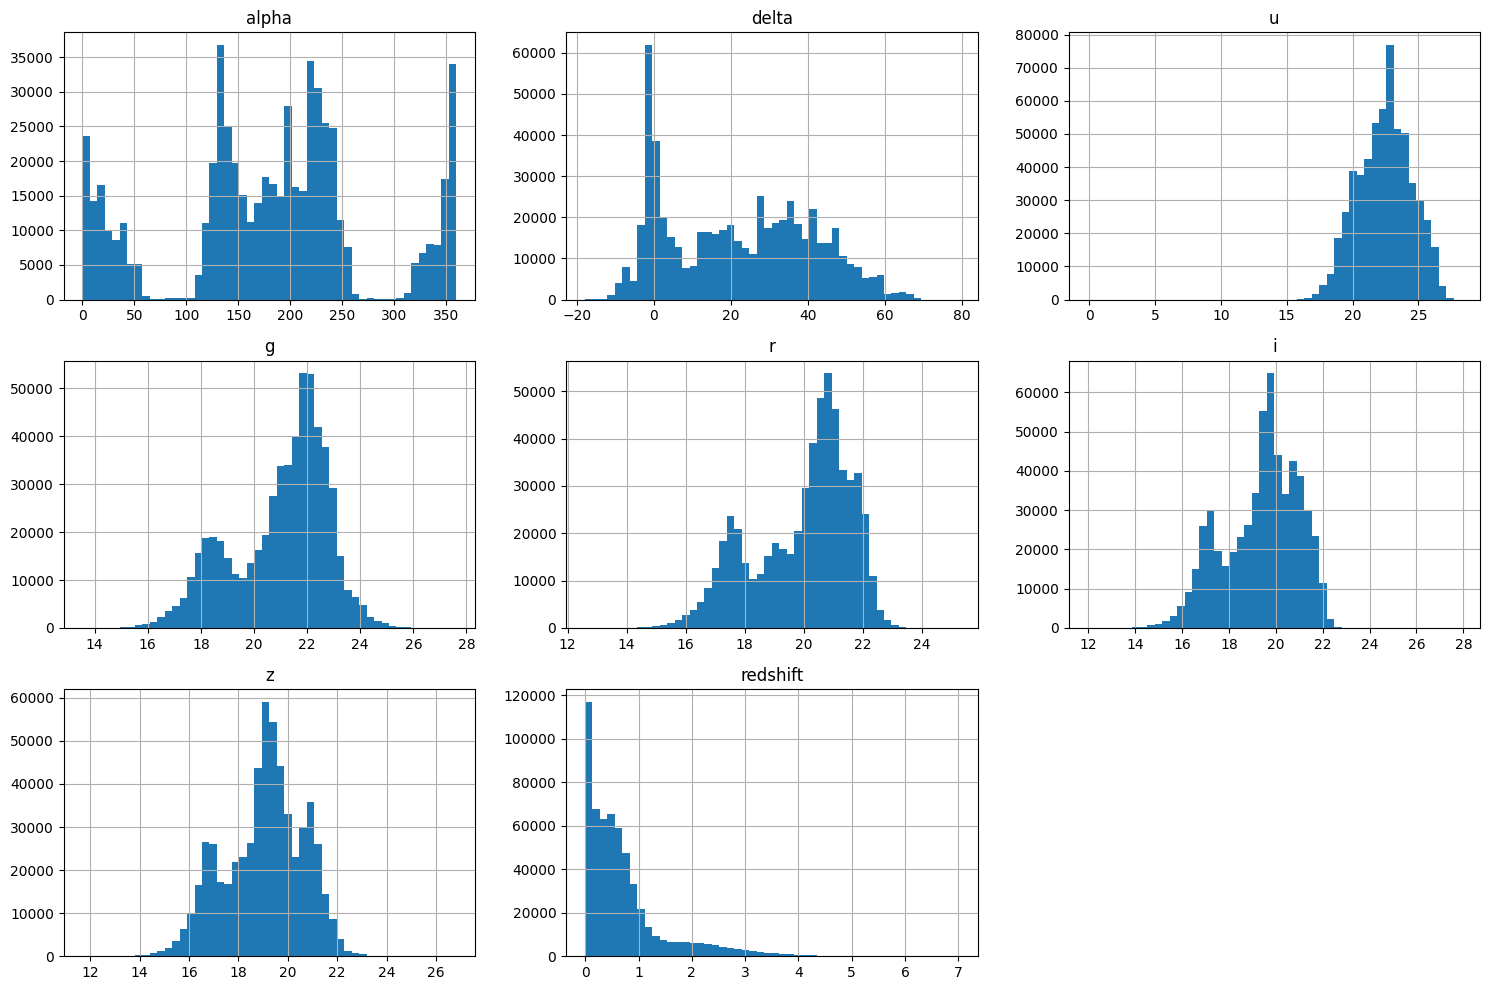

In [6]:
train_df.hist(figsize=(15, 10), bins=50)
plt.tight_layout()
plt.show()


- **`alpha` e `delta`** têm distribuição larga e irregular, típica da área do céu coberta pelo levantamento.
- **As magnitudes** são aproximadamente simétricas, com leve cauda à esquerda (objetos muito brilhantes), com exceção de alguns valores de `u` perto de 0, investigados em inconsistências.
- **`redshift` é bem assimétrico à direita** (assimetria 2,3): a maioria dos objetos fica abaixo de 1, e uma cauda longa chega a 7. Essa cauda é quase toda de quasares.

### Distribuição das variáveis categóricas

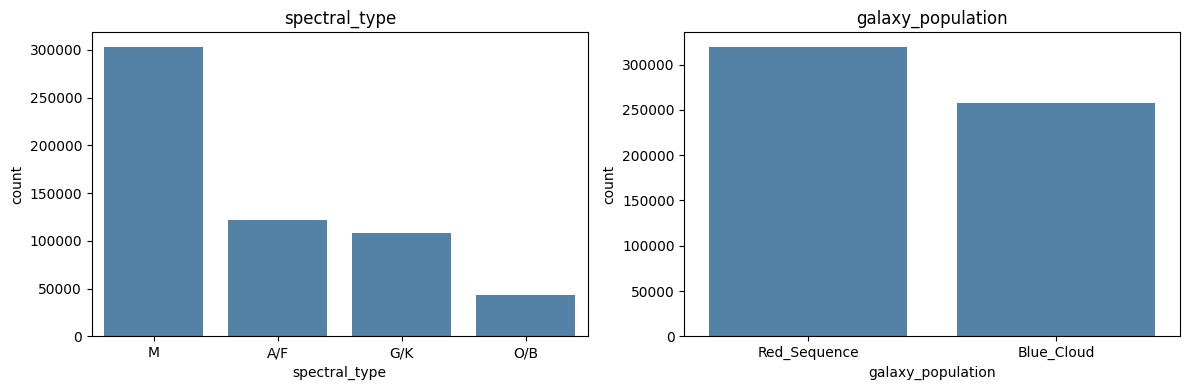

assimetria das numéricas


alpha      -0.06
delta       0.18
u          -0.12
g          -0.63
r          -0.66
i          -0.48
z          -0.31
redshift    2.30
dtype: float64

In [ ]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))
for eixo, coluna in zip(eixos, categoricas):
    sns.countplot(x=train_df[coluna], order=train_df[coluna].value_counts().index, ax=eixo, color='steelblue')
    eixo.set_title(coluna)
plt.tight_layout()
plt.show()

print('assimetria das numéricas')
train_df[numericas].skew().round(2)

- **`spectral_type` é dominado por M** (52,5%), seguido de A/F, G/K e O/B (7,5%).
- **`galaxy_population` é quase meio a meio**, com Red_Sequence (55%) um pouco à frente de Blue_Cloud (45%).
- **Categorias iguais nas duas bases:** treino e teste têm as mesmas categorias nas mesmas proporções, o que é conferido nas inconsistências.

### Correlação entre variáveis

In [7]:
train_df.select_dtypes(include='number').corr()

,alpha,delta,u,g,r,i,z,redshift
alpha,1.000000,0.143541,-0.017242,-0.037731,-0.037830,-0.029333,-0.024583,0.007989
delta,0.143541,1.000000,-0.026860,-0.008386,-0.004395,0.002088,0.003347,0.053763
u,-0.017242,-0.026860,1.000000,0.826880,0.659410,0.521811,0.443923,0.078903
g,-0.037731,-0.008386,0.826880,1.000000,0.912066,0.805020,0.731737,0.237447
r,-0.037830,-0.004395,0.659410,0.912066,1.000000,0.953550,0.913341,0.390989
i,-0.029333,0.002088,0.521811,0.805020,0.953550,1.000000,0.968715,0.466575
z,-0.024583,0.003347,0.443923,0.731737,0.913341,0.968715,1.000000,0.480860
redshift,0.007989,0.053763,0.078903,0.237447,0.390989,0.466575,0.480860,1.000000


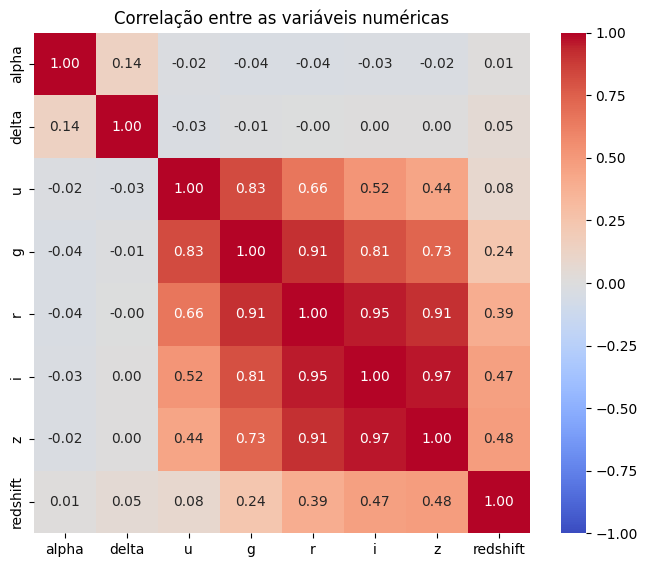

In [ ]:
plt.figure(figsize=(8, 6.5))
sns.heatmap(train_df[numericas].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlação entre as variáveis numéricas')
plt.show()

- **As magnitudes são fortemente correlacionadas entre si**, sobretudo as vizinhas: g e r 0,91, r e i 0,95, i e z 0,97. Um objeto brilhante é brilhante em todos os filtros. Por isso a informação útil não está no brilho absoluto, e sim na **diferença entre filtros** (a cor do objeto), o que motiva o feature engineering.
- **O redshift cresce com as magnitudes vermelhas** (0,47 com i). Objetos mais distantes parecem mais fracos.
- **`alpha` e `delta` quase não se correlacionam com nada.**

### Relação com o target

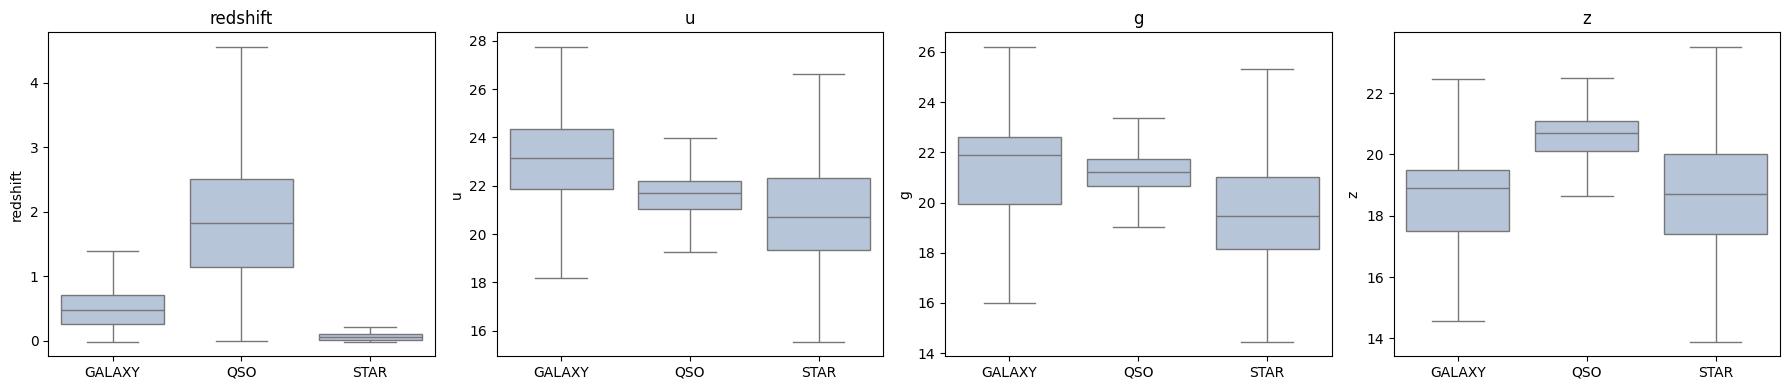

,alpha,delta,u,g,r,i,z,redshift
class,,,,,,,,
GALAXY,191.988,20.015,23.139,21.917,20.330,19.399,18.928,0.482
QSO,186.152,29.279,21.701,21.246,21.013,20.869,20.698,1.799
STAR,188.069,19.567,20.758,19.507,19.034,18.816,18.696,0.056


In [ ]:
# numa amostra de 50 mil linhas, para os gráficos ficarem legíveis; as medianas usam a base inteira
amostra = train_df.sample(50_000, random_state=RANDOM_STATE)
classe_amostra = target_col.loc[amostra.index]
ordem = ['GALAXY', 'QSO', 'STAR']

fig, eixos = plt.subplots(1, 4, figsize=(18, 4))
for eixo, coluna in zip(eixos, ['redshift', 'u', 'g', 'z']):
    sns.boxplot(x=classe_amostra, y=amostra[coluna], order=ordem, ax=eixo, color='lightsteelblue', showfliers=False)
    eixo.set_title(coluna)
    eixo.set_xlabel('')
plt.tight_layout()
plt.show()

pd.concat([train_df[numericas], target_col], axis=1).groupby(TARGET).median().round(3)

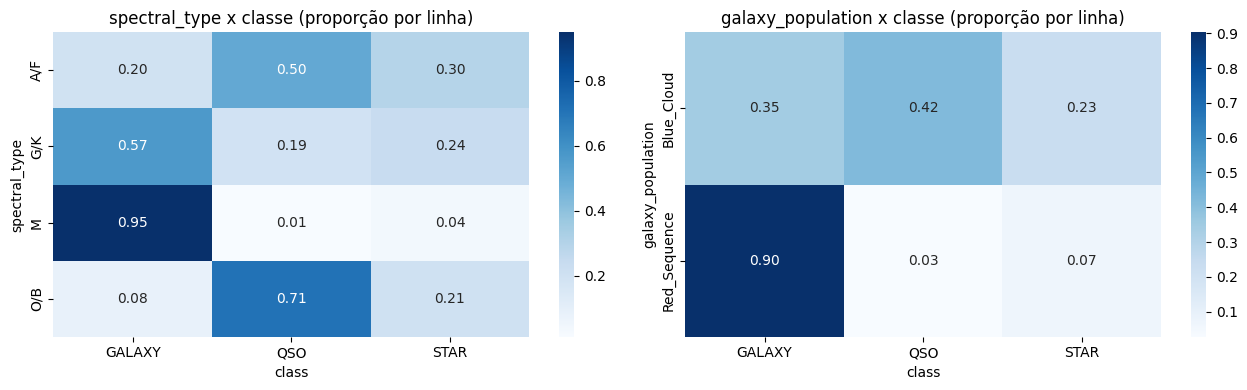

In [ ]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 4))
for eixo, coluna in zip(eixos, categoricas):
    sns.heatmap(pd.crosstab(train_df[coluna], target_col, normalize='index'), annot=True, fmt='.2f', cmap='Blues', ax=eixo)
    eixo.set_title(f'{coluna} x classe (proporção por linha)')
plt.tight_layout()
plt.show()

- **O redshift é a variável numérica que mais separa as classes.** As medianas são 0,06 para estrela, 0,48 para galáxia e 1,80 para quasar. Estrelas estão na nossa galáxia e quase não se afastam; quasares estão muito longe.
- **Nas magnitudes, as classes se sobrepõem bastante.** O que as distingue é o formato do espectro: a galáxia cai de 23,1 no u para 18,9 no z, enquanto o quasar fica quase plano (21,7 a 20,7).
- **As categóricas são muito informativas:**
  - M é galáxia em 95% dos casos;
  - O/B é quasar em 71%;
  - Red_Sequence é galáxia em 90%;
  - Blue_Cloud é onde as três classes se misturam.

### Distribuição das classes

In [8]:
target_col.value_counts(normalize=True)

class
GALAXY    0.653818
QSO       0.202899
STAR      0.143283
Name: proportion, dtype: float64

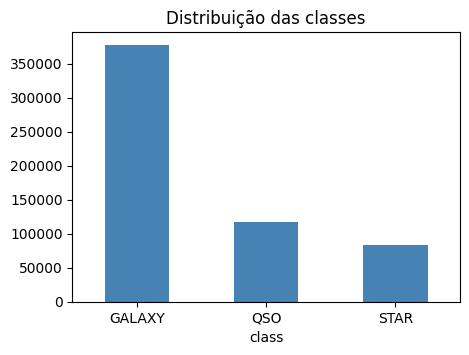

In [ ]:
target_col.value_counts().plot.bar(color='steelblue', rot=0, figsize=(5, 3.5))
plt.title('Distribuição das classes')
plt.show()

As classes são **desbalanceadas**: GALAXY tem 65,4%, QSO 20,3% e STAR 14,3%. Um modelo que chutasse sempre GALAXY teria 65% de acurácia e 33% de balanced accuracy. Por isso:
- a separação treino e validação é estratificada (`stratify=y`);
- a métrica é a **balanced accuracy**, que dá o mesmo peso ao acerto de cada classe;
- a matriz de confusão é normalizada por linha, para mostrar o recall de cada classe.

### Valores faltantes

ausentes no target: 0


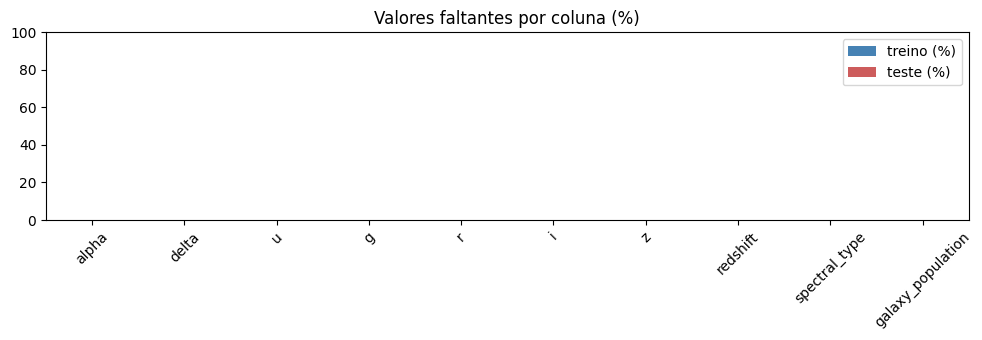

,treino (%),teste (%)
alpha,0.0,0.0
delta,0.0,0.0
u,0.0,0.0
g,0.0,0.0
r,0.0,0.0
i,0.0,0.0
z,0.0,0.0
redshift,0.0,0.0
spectral_type,0.0,0.0
galaxy_population,0.0,0.0


In [ ]:
faltantes = pd.DataFrame({
    'treino (%)': train_df.isna().mean() * 100,
    'teste (%)': test_df.drop(columns='id').isna().mean() * 100,
})
print('ausentes no target:', target_col.isna().sum())

faltantes.plot.bar(figsize=(10, 3.5), ylim=(0, 100), rot=45, color=['steelblue', 'indianred'])
plt.title('Valores faltantes por coluna (%)')
plt.tight_layout()
plt.show()
faltantes

Não há nenhum valor faltante, nem no treino, nem no teste, nem no target. O gráfico fica vazio de propósito: todas as colunas estão em 0%.

### Outliers

classe dos outliers de redshift: {'QSO': 0.999, 'GALAXY': 0.001, 'STAR': 0.0}


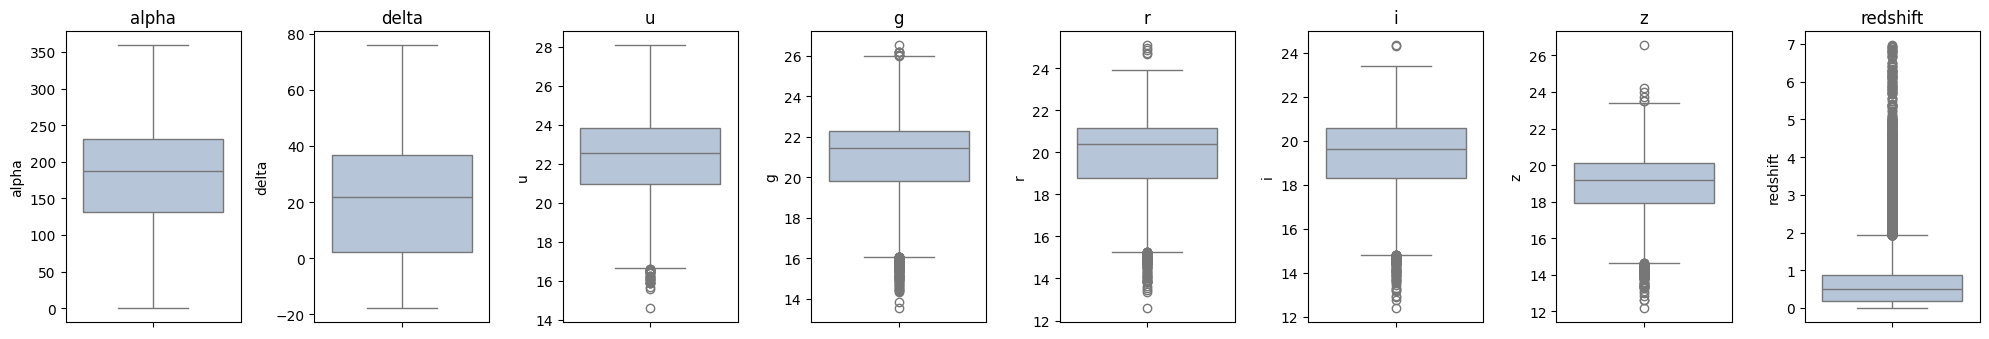

,outliers,% dos registros
alpha,0,0.00
delta,0,0.00
u,315,0.05
g,2806,0.49
r,1677,0.29
i,1277,0.22
z,1476,0.26
redshift,52590,9.11


In [ ]:
# regra do IQR: fora de [Q1 - 1,5 IQR, Q3 + 1,5 IQR]
q1, q3 = train_df[numericas].quantile(0.25), train_df[numericas].quantile(0.75)
iqr = q3 - q1
fora = (train_df[numericas] < q1 - 1.5 * iqr) | (train_df[numericas] > q3 + 1.5 * iqr)
print('classe dos outliers de redshift:', target_col[fora['redshift']].value_counts(normalize=True).round(3).to_dict())

fig, eixos = plt.subplots(1, len(numericas), figsize=(20, 3.5))
for eixo, coluna in zip(eixos, numericas):
    sns.boxplot(y=amostra[coluna], ax=eixo, color='lightsteelblue')
    eixo.set_title(coluna)
plt.tight_layout()
plt.show()

pd.DataFrame({'outliers': fora.sum(), '% dos registros': (fora.mean() * 100).round(2)})

- **O redshift concentra os outliers** (9,1% dos registros), e 99,9% deles são quasares. Não é erro: é justamente o que caracteriza a classe. Remover esses pontos apagaria o sinal mais forte do quasar.
- **Nas magnitudes, os outliers são poucos** (menos de 0,5% por coluna) e ficam dentro do intervalo físico, exceto os casos de `u` perto de 0 abaixo.
- **`alpha` e `delta` não têm outlier.**

### Inconsistências e problemas nos dados

In [ ]:
negativo = train_df['redshift'] < 0
print('redshift negativo:', negativo.sum(), f'({negativo.mean():.2%})', target_col[negativo].value_counts().to_dict())
print('menor redshift:', round(train_df['redshift'].min(), 4))
print('magnitude u abaixo de 10:', (train_df['u'] < 10).sum(), '| classes:', target_col[train_df['u'] < 10].value_counts().to_dict())
print('estrelas com redshift acima de 1:', ((target_col == 'STAR') & (train_df['redshift'] > 1)).sum())
print('categorias do teste que não existem no treino:', {c: set(test_df[c]) - set(train_df[c]) for c in categoricas})

redshift negativo: 8957 (1.55%) {'STAR': 6498, 'GALAXY': 2459}
menor redshift: -0.01
magnitude u abaixo de 10: 3 | classes: {'STAR': 3}
estrelas com redshift acima de 1: 7
categorias do teste que não existem no treino: {'spectral_type': set(), 'galaxy_population': set()}


- **Redshift negativo:** 8.957 registros (1,55%), quase todos de estrelas e galáxias, com mínimo de -0,01. É ruído de medida em torno de zero (ou movimento de aproximação, no caso de estrelas próximas). O valor é mantido, e só a feature `log_redshift` corta em 0, porque o log não aceita negativo.
- **Magnitude `u` perto de 0:** 3 registros de estrela. Uma magnitude 0 no ultravioleta seria um dos objetos mais brilhantes do céu, o que não combina com as outras bandas (acima de 19). É erro de medida. Com 3 linhas em 577 mil, o efeito é desprezível, e os modelos de árvore não são sensíveis a esse tipo de valor.
- **Estrelas com redshift acima de 1:** 7 registros. É fisicamente implausível e pode ser rótulo errado, mas o volume é desprezível.
- **Treino e teste têm as mesmas categorias**, então o one-hot feito separadamente nas duas bases gera as mesmas colunas.

### Principais insights da EDA

1. **Redshift e as categóricas carregam a maior parte do sinal.** O redshift separa estrela, galáxia e quasar quase sozinho, e M e Red_Sequence apontam para galáxia com 90% ou mais.
2. **O brilho absoluto quase não importa; a cor importa.** As magnitudes são muito correlacionadas entre si, e a diferença entre filtros é que distingue as classes.
3. **A posição no céu (`alpha`, `delta`) não separa as classes.**
4. **A base é limpa:** sem ausentes, sem duplicados e com poucas inconsistências, todas de volume desprezível.
5. **As classes são desbalanceadas,** o que pede estratificação e balanced accuracy.

## 4. Tratamento e pré-processamento

In [ ]:
print('linhas duplicadas no treino (atributos):', train_df.duplicated().sum())
print('linhas duplicadas no treino (atributos + classe):', pd.concat([train_df, target_col], axis=1).duplicated().sum())
print('linhas duplicadas no teste:', test_df.drop(columns='id').duplicated().sum())
print('ids repetidos no teste:', test_df['id'].duplicated().sum())

linhas duplicadas no treino (atributos): 0


linhas duplicadas no treino (atributos + classe): 0


linhas duplicadas no teste: 0
ids repetidos no teste: 0


Decisões e justificativas:

| Etapa | Decisão | Por quê |
| --- | --- | --- |
| Valores faltantes | nenhum tratamento | não há nenhum ausente em treino, teste ou target |
| Duplicados | nenhum tratamento | não há linha repetida nem id repetido |
| Outliers | mantidos | os de redshift são o sinal do quasar; os demais são poucos, e árvores não são sensíveis a eles |
| Redshift negativo | mantido; cortado em 0 só no `log_redshift` | é ruído em torno de zero, e o log não aceita negativo |
| `id` | removido dos atributos | é só identificador, não tem informação sobre a classe |
| Encoding das categóricas | one-hot (`pd.get_dummies`) | ver a seção de encoding, antes do treino |
| Encoding do target | `LabelEncoder` | o XGBoost exige classes numeradas de 0 a k-1 |
| Normalização | não aplicada | XGBoost e CatBoost dividem por limiar e não dependem de escala |

### Feature engineering

**Oportunidades identificadas na EDA:**

- **Cores (`u_g`, `g_r`, `r_i`, `i_z`, `u_z`).** As magnitudes estão muito correlacionadas porque todas medem o brilho do mesmo objeto. A diferença entre dois filtros, que em astronomia se chama índice de cor, tira o efeito do brilho e da distância e deixa só o formato do espectro, que é o que distingue as classes. `u_z` é a cor mais longa e resume a inclinação do espectro inteiro.
- **`log_redshift`.** O redshift é a variável mais forte, mas é muito assimétrico (2,3). O log comprime a cauda dos quasares e dá mais resolução na faixa entre 0 e 1, onde estrela e galáxia se separam. O corte em 0 trata o redshift negativo, que é ruído.
- **`abs_delta`.** É a distância ao equador celeste, sem o sinal. É uma hipótese a testar: a posição sozinha não separou as classes na EDA.

In [ ]:
for df in [train_df, test_df]:
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['u_z'] = df['u'] - df['z']
    df['log_redshift'] = np.log1p(df['redshift'].clip(lower=0))
    df['abs_delta'] = df['delta'].abs()

### EDA das novas features

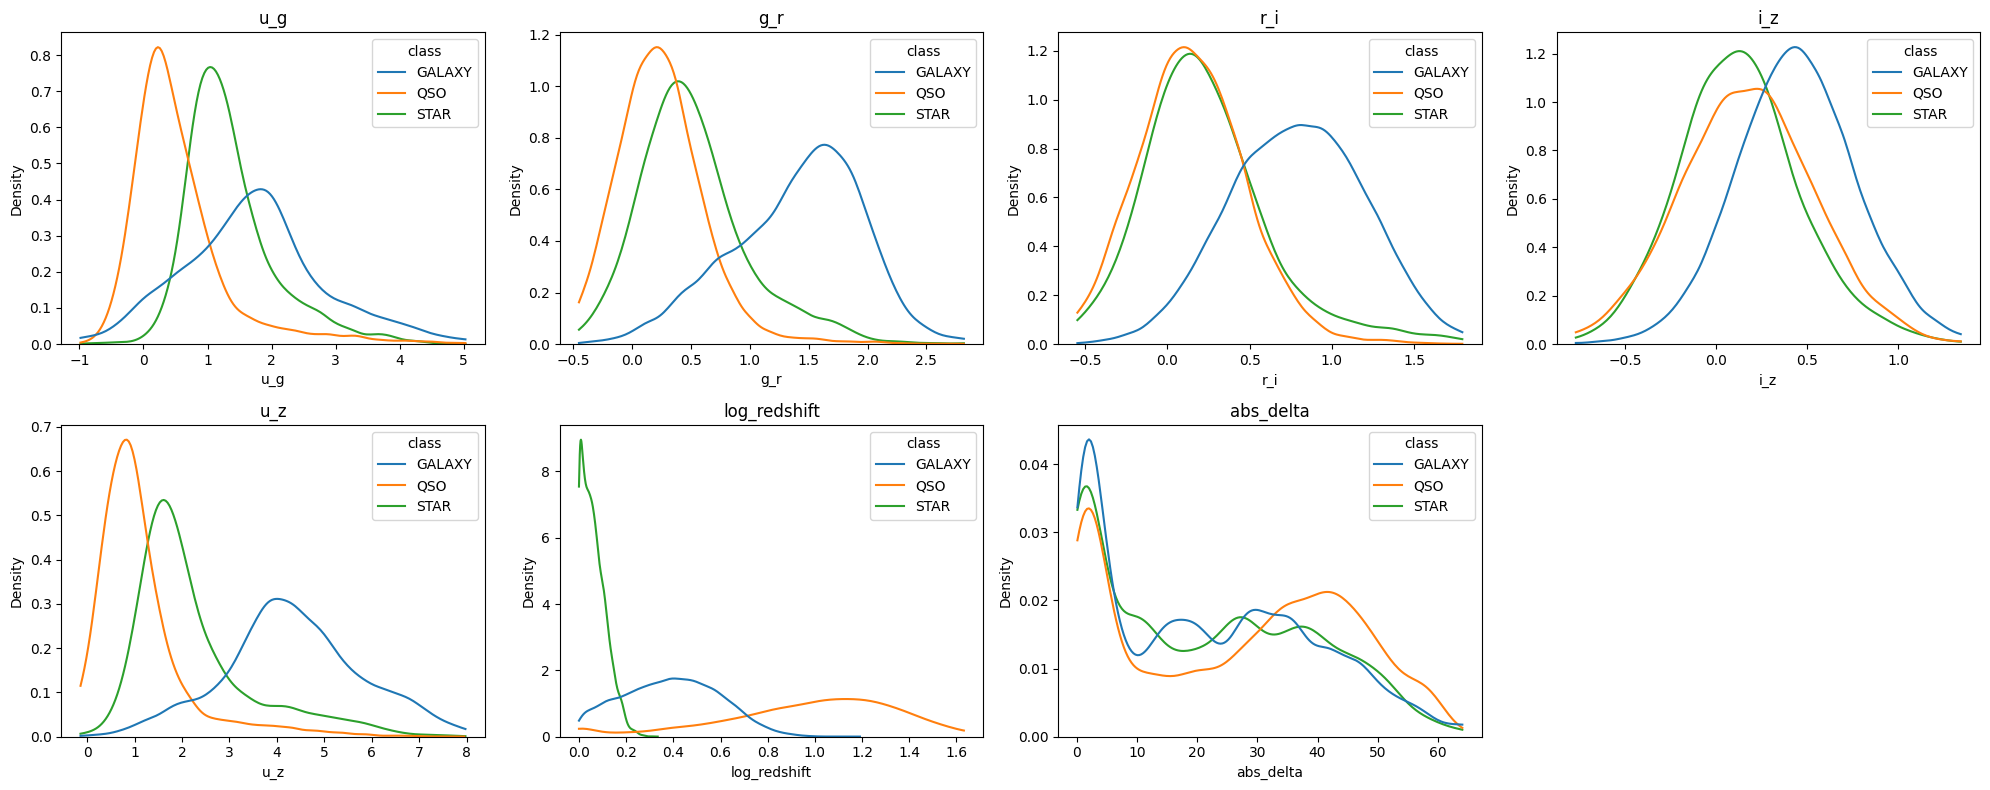

,u_g,g_r,r_i,i_z,u_z,log_redshift,abs_delta
class,,,,,,,
GALAXY,1.694,1.481,0.795,0.437,4.288,0.393,20.015
QSO,0.383,0.214,0.141,0.168,0.906,1.029,29.279
STAR,1.221,0.453,0.193,0.119,1.875,0.055,19.567


In [ ]:
novas = ['u_g', 'g_r', 'r_i', 'i_z', 'u_z', 'log_redshift', 'abs_delta']
amostra = train_df.sample(50_000, random_state=RANDOM_STATE)
classe_amostra = target_col.loc[amostra.index]

fig, eixos = plt.subplots(2, 4, figsize=(20, 8))
eixos = eixos.flatten()
for eixo, coluna in zip(eixos, novas):
    limites = tuple(amostra[coluna].quantile([0.005, 0.995]))
    sns.kdeplot(x=amostra[coluna], hue=classe_amostra, hue_order=ordem, common_norm=False, clip=limites, ax=eixo)
    eixo.set_title(coluna)
eixos[-1].axis('off')
plt.tight_layout()
plt.show()

pd.concat([train_df[novas], target_col], axis=1).groupby(TARGET).median().round(3)

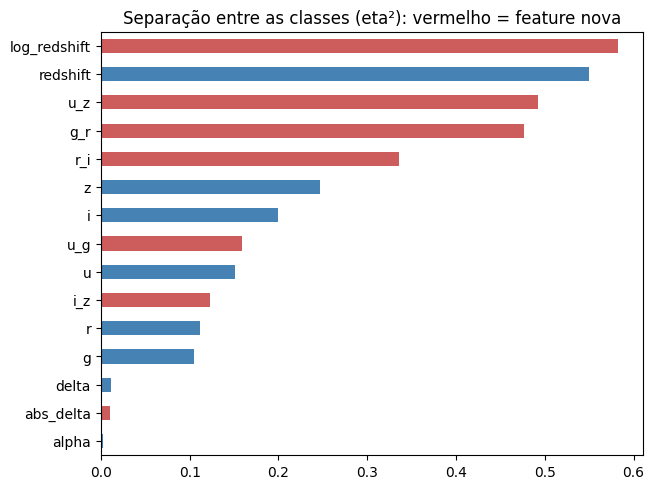

log_redshift    0.582
redshift        0.550
u_z             0.492
g_r             0.476
r_i             0.335
z               0.247
i               0.199
u_g             0.159
u               0.151
i_z             0.123
r               0.112
g               0.105
delta           0.012
abs_delta       0.011
alpha           0.002
dtype: float64

In [ ]:
# eta²: fração da variância da feature explicada pela classe (0 = não separa, 1 = separa totalmente)
def eta2(coluna):
    media = coluna.mean()
    grupos = coluna.groupby(target_col)
    return (grupos.count() * (grupos.mean() - media) ** 2).sum() / ((coluna - media) ** 2).sum()

separacao = pd.Series({c: eta2(train_df[c]) for c in numericas + novas}).sort_values()
cores = ['indianred' if c in novas else 'steelblue' for c in separacao.index]
separacao.plot.barh(figsize=(7, 5.5), color=cores)
plt.title('Separação entre as classes (eta²): vermelho = feature nova')
plt.show()

separacao.sort_values(ascending=False).round(3)

assimetria do redshift: 2.3 | do log_redshift: 1.07


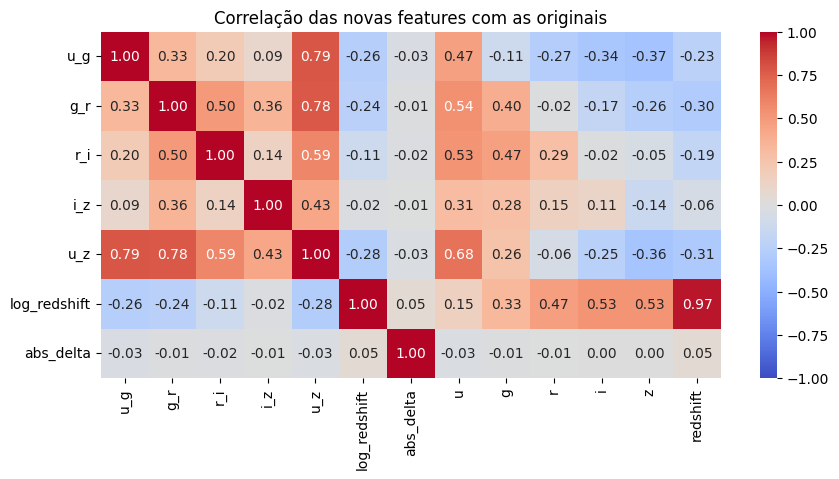

In [ ]:
print('assimetria do redshift:', round(train_df['redshift'].skew(), 2), '| do log_redshift:', round(train_df['log_redshift'].skew(), 2))

plt.figure(figsize=(10, 4.5))
sns.heatmap(train_df[novas + ['u', 'g', 'r', 'i', 'z', 'redshift']].corr().loc[novas], annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlação das novas features com as originais')
plt.show()

**Resultado e justificativa das novas features:**

- **Três cores separam as classes muito melhor que as magnitudes de origem.** O eta² de `u_z` é 0,49, o de `g_r` é 0,48 e o de `r_i` é 0,34, contra 0,10 a 0,25 das magnitudes sozinhas. `u_g` (0,16) e `i_z` (0,12) ficam no nível das magnitudes. Mesmo assim, `u_g` se justifica: é a cor que separa **quasar de estrela** (medianas 0,38 e 1,22), justamente o par que `g_r` e `r_i` deixam sobreposto no gráfico. O eta² mede a separação das três classes de uma vez e não mostra isso. Nas medianas:
  - a galáxia é vermelha (`g_r` 1,48, `u_z` 4,29);
  - o quasar é quase plano (`g_r` 0,21, `u_z` 0,91);
  - a estrela fica no meio.
- **`log_redshift` é a feature que mais separa** (eta² 0,58, contra 0,55 do redshift original), e a assimetria cai de 2,3 para 1,07. A correlação com o redshift é 0,97, então para árvores ela é quase redundante. O ganho está na resolução da faixa baixa e na leitura dos gráficos.
- **`u_z` repete parte de `u_g` e `g_r`** (correlação 0,79 e 0,78), porque é a soma das cores intermediárias. Para modelos de árvore isso não atrapalha.
- **`abs_delta` não separa as classes** (eta² 0,011, igual ao `delta` original). A hipótese não se confirmou; a feature fica no modelo, mas quase não pesa, como a importância mostra abaixo.

In [10]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split

### Encoding das variáveis categóricas e padronização

- **`spectral_type` e `galaxy_population`: one-hot.** São nominais: o tipo espectral tem uma sequência física (O, B, A, F, G, K, M, da mais quente para a mais fria), mas a relação com a classe não é monotônica. M é galáxia, O/B é quasar e A/F mistura as três, então codificar como 0 a 3 imporia uma ordem que não ajuda. Com 4 e 2 categorias, o one-hot cria só 6 colunas.
- **`class` (target): `LabelEncoder`.** O XGBoost precisa das classes como inteiros de 0 a k-1; `le.inverse_transform` devolve o nome na hora da submissão.
- **O `OneHotEncoder` criado no início não é usado:** o one-hot é feito com `pd.get_dummies`, separadamente em treino e teste. Isso só funciona porque as duas bases têm exatamente as mesmas categorias, o que é conferido logo abaixo.
- **Padronização não é necessária.** XGBoost e CatBoost dividem cada variável por limiares, e o resultado não muda com a escala.

In [11]:
train_df = pd.get_dummies(train_df, columns=['spectral_type', 'galaxy_population'])
test_df = pd.get_dummies(test_df, columns=['spectral_type', 'galaxy_population'])

In [ ]:
# o one-hot em treino e teste separados só é válido se gerar as mesmas colunas, na mesma ordem
assert list(train_df.columns) == list(test_df.drop(columns='id').columns)
print('colunas do one-hot:', [c for c in train_df.columns if c.startswith(('spectral_type_', 'galaxy_population_'))])
print('treino:', train_df.shape, '| teste:', test_df.drop(columns='id').shape)

colunas do one-hot: ['spectral_type_A/F', 'spectral_type_G/K', 'spectral_type_M', 'spectral_type_O/B', 'galaxy_population_Blue_Cloud', 'galaxy_population_Red_Sequence']
treino: (577347, 21) | teste: (247435, 21)


In [12]:
train_df.head(10)

,alpha,delta,u,g,r,i,z,redshift,u_g,g_r,r_i,i_z,log_redshift,abs_delta,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,galaxy_population_Blue_Cloud,galaxy_population_Red_Sequence
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,3.576564,1.537632,1.100813,0.636056,0.342868,16.959273,False,False,True,False,False,True
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,1.691447,1.499854,0.361141,0.439634,0.146673,32.346716,False,False,True,False,False,True
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,-0.043925,-0.092712,0.589211,0.025263,1.341237,35.344843,False,False,False,True,True,False
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,2.254320,2.032982,0.652096,0.450706,0.429246,48.569421,False,False,True,False,False,True
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,2.231478,1.237231,0.335002,0.283262,0.441965,19.342852,False,False,True,False,False,True
5,250.727869,31.756548,20.926469,19.693480,18.902361,19.247572,18.508241,0.076299,1.232989,0.791119,-0.345211,0.739331,0.073528,31.756548,False,True,False,False,True,False
6,0.752529,-2.936677,22.829195,22.686143,20.583886,19.781338,19.410491,0.575080,0.143052,2.102257,0.802549,0.370847,0.454306,2.936677,False,False,True,False,False,True
7,235.611325,39.626517,22.511467,21.480306,21.765645,21.508658,21.333476,2.159269,1.031161,-0.285339,0.256987,0.175182,1.150341,39.626517,False,False,False,True,True,False
8,355.359230,2.182312,20.396550,20.064767,19.892257,19.836272,19.860081,0.900087,0.331783,0.172510,0.055985,-0.023809,0.641900,2.182312,True,False,False,False,True,False
9,254.980080,38.743449,18.839137,17.997845,18.458894,18.229552,19.202247,0.114302,0.841292,-0.461050,0.229342,-0.972695,0.108228,38.743449,False,False,False,True,True,False


In [13]:
X = train_df
y = target_col

y = le.fit_transform(y)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y)

In [14]:
xgbc_model = XGBClassifier(
    subsample=0.9,
    reg_lambda=0.5,
    reg_alpha=0.1,
    n_estimators=700,
    min_child_weight=5,
    max_depth=6,
    learning_rate=0.1,
    gamma=0,
    colsample_bytree=0.7,
    random_state=RANDOM_STATE,
    objective='multi:softprob',
    eval_metric='mlogloss',
    early_stopping_rounds=30,
    n_jobs=-1,
    tree_method='hist'
)
xgbc_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)

[0]	validation_0-mlogloss:0.77501
[100]	validation_0-mlogloss:0.10408
[200]	validation_0-mlogloss:0.09625
[300]	validation_0-mlogloss:0.09311
[400]	validation_0-mlogloss:0.09184
[500]	validation_0-mlogloss:0.09128
[600]	validation_0-mlogloss:0.09090
[699]	validation_0-mlogloss:0.09081


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from

In [15]:
y_pred_xgb = xgbc_model.predict(X_val)

In [16]:
pd.Series(xgbc_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

spectral_type_M                   0.394998
galaxy_population_Blue_Cloud      0.310050
log_redshift                      0.064278
redshift                          0.049991
galaxy_population_Red_Sequence    0.035533
spectral_type_O/B                 0.028440
g_r                               0.026033
z                                 0.018221
g                                 0.011851
r_i                               0.010676
u                                 0.010259
u_g                               0.009387
i                                 0.005993
spectral_type_G/K                 0.005960
r                                 0.004319
alpha                             0.003874
i_z                               0.002627
abs_delta                         0.002620
delta                             0.002460
spectral_type_A/F                 0.002432
dtype: float32

**Leitura da importância (XGBoost):**
- **As duas categóricas dominam:** `spectral_type_M` (0,39) e `galaxy_population_Blue_Cloud` (0,31) somam 70% da importância. Isso confirma a EDA: elas separam galáxia do resto quase sozinhas.
- **O redshift vem em seguida:** `log_redshift` (0,064) e `redshift` (0,050). A versão em log é a mais usada das duas.
- **Entre as cores, `g_r` é a mais útil** (0,026), à frente de qualquer magnitude isolada.
- **`abs_delta`, `alpha` e `delta` ficam no fim**, como a EDA previa.

In [17]:
catboost_model = CatBoostClassifier(
    iterations=700,
    depth=6,
    learning_rate=0.1,
    loss_function='MultiClass',
    eval_metric='TotalF1:average=Macro',
    l2_leaf_reg=3,
    random_seed=RANDOM_STATE,
    verbose=100,
    thread_count=-1
)
catboost_model.fit(X_train, y_train, eval_set=(X_val, y_val))

0:	learn: 0.8750350	test: 0.8748784	best: 0.8748784 (0)	total: 1.44s	remaining: 16m 48s
100:	learn: 0.9422041	test: 0.9419113	best: 0.9419113 (100)	total: 31.3s	remaining: 3m 5s
200:	learn: 0.9489901	test: 0.9478244	best: 0.9479906 (196)	total: 1m	remaining: 2m 31s
300:	learn: 0.9516590	test: 0.9496707	best: 0.9496854 (298)	total: 1m 34s	remaining: 2m 5s
400:	learn: 0.9532854	test: 0.9511605	best: 0.9511605 (400)	total: 2m 1s	remaining: 1m 30s
500:	learn: 0.9544963	test: 0.9520240	best: 0.9520240 (500)	total: 2m 29s	remaining: 59.3s
600:	learn: 0.9556450	test: 0.9525543	best: 0.9525577 (584)	total: 3m 24s	remaining: 33.7s
699:	learn: 0.9564306	test: 0.9530473	best: 0.9530489 (698)	total: 4m 16s	remaining: 0us

bestTest = 0.9530488705
bestIteration = 698

Shrink model to first 699 iterations.


CatBoostClassifier(depth=6, eval_metric='TotalF1:average=Macro', iterations=700, l2_leaf_reg=3, learning_rate=0.1, loss_function='MultiClass', random_seed=42, verbose=100)

## Results:

In [18]:
# Catboost:
y_pred_cat = catboost_model.predict(X_val).flatten()
print(f"CatBoost model: {balanced_accuracy_score(y_val, y_pred_cat)}")

# XGBoost:
print(f"XGBoost model: {balanced_accuracy_score(y_val, y_pred_xgb)}")

# Ensemble (soft voting):
proba_xgb = xgbc_model.predict_proba(X_val)
proba_cat = catboost_model.predict_proba(X_val)
ensemble_preds = np.argmax(proba_xgb + proba_cat, axis=1)
print(f"Ensemble model: {balanced_accuracy_score(y_val, ensemble_preds)}")

CatBoost model: 0.951741179312295
XGBoost model: 0.9545399685254948
Ensemble model: 0.9548749235853453


**Leitura dos resultados:**
- **Os dois modelos acertam cerca de 95% em balanced accuracy:** CatBoost 0,952 e XGBoost 0,955. É muito acima dos 33% de um modelo que chutasse sempre GALAXY.
- **O ensemble por soma de probabilidades melhora pouco** (0,955). Os dois modelos erram nos mesmos objetos, então combinar rende quase nada.
- **Os números vêm de uma única separação de validação** (20%), e `train_test_split` está sem `random_state`. Rodar de novo muda os valores na terceira casa decimal.

In [19]:
test_ids = test_df['id']
X_test = test_df.drop(columns=['id'])

# XGBoost submission
xgb_preds = le.inverse_transform(xgbc_model.predict(X_test))
pd.DataFrame({'id': test_ids, 'class': xgb_preds}).to_csv('submission_xgb.csv', index=False)

# CatBoost submission
cat_preds = le.inverse_transform(catboost_model.predict(X_test).flatten().astype(int))
pd.DataFrame({'id': test_ids, 'class': cat_preds}).to_csv('submission_catboost.csv', index=False)

# Ensemble submission
proba_xgb_test = xgbc_model.predict_proba(X_test)
proba_cat_test = catboost_model.predict_proba(X_test)
ensemble_preds_test = le.inverse_transform(np.argmax(proba_xgb_test + proba_cat_test, axis=1))
pd.DataFrame({'id': test_ids, 'class': ensemble_preds_test}).to_csv('submission_ensemble.csv', index=False)

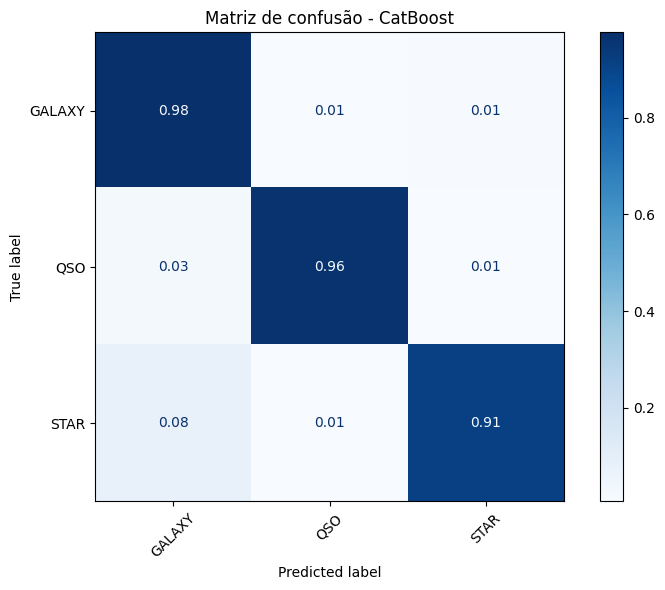

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred_cat.astype(int),
    display_labels=le.classes_,
    normalize='true',
    cmap='Blues',
    values_format='.2f',
    ax=ax
)

ax.set_title('Matriz de confusão - CatBoost')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Principais highlights

- **A classe mais difícil é a estrela:** 91% de recall no CatBoost, contra 98% da galáxia e 96% do quasar. **8% das estrelas são classificadas como galáxia**, que é o principal erro do modelo. Faz sentido: estrelas e galáxias próximas têm redshift perto de zero e cores parecidas.
- **O quasar, a classe mais valiosa para a triagem, tem 96% de recall.** Quando erra, ele é confundido com galáxia (3%).
- **O que decide a classe é o tipo espectral, a população de cor e o redshift.** A posição no céu não contribui.
- **O feature engineering se justificou nas cores e no log do redshift.** `u_z`, `g_r` e `r_i` separam as classes de 1,4 a 4,7 vezes melhor que as magnitudes isoladas. `abs_delta` não contribuiu.
- **A base não precisou de limpeza pesada:** sem ausentes nem duplicados, e as poucas inconsistências (redshift negativo, `u` perto de 0) têm volume desprezível.